In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("DailyDelhiClimateTrain.csv")
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
5,2013-01-06,7.000000,82.800000,1.480000,1018.000000
6,2013-01-07,7.000000,78.600000,6.300000,1020.000000
7,2013-01-08,8.857143,63.714286,7.142857,1018.714286
8,2013-01-09,14.000000,51.250000,12.500000,1017.000000
9,2013-01-10,11.000000,62.000000,7.400000,1015.666667


# Ambil kolom suhu rata-rata harian

In [ ]:
T_env = data["meantemp"].values  

# Sumbu waktu (hari)

In [6]:
days = np.arange(len(T_env)) 

# Simulasi pendinginan dengan data nyata

In [7]:
def simulate_cooling(T_env, T0=40, k=0.05):
    T = T0  # Suhu awal objek = 40°C
    T_simulated = []
    for Tenv in T_env:
        dT = -k * (T - Tenv)
        T += dT
        T_simulated.append(T)
    return T_simulated

T_sim = simulate_cooling(T_env)

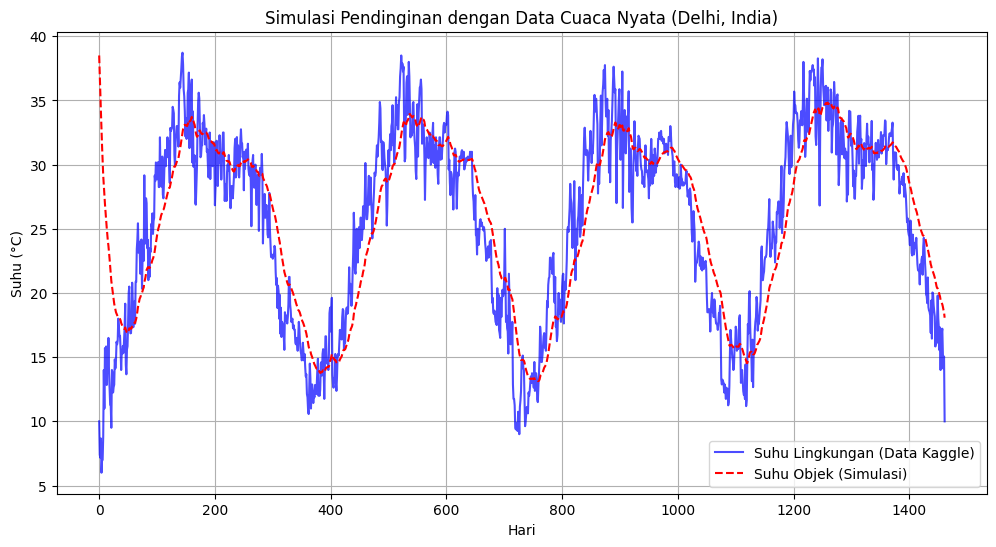

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(days, T_env, label="Suhu Lingkungan (Data Kaggle)", color="blue", alpha=0.7)
plt.plot(days, T_sim, label="Suhu Objek (Simulasi)", color="red", linestyle="--")
plt.xlabel("Hari")
plt.ylabel("Suhu (°C)")
plt.title("Simulasi Pendinginan dengan Data Cuaca Nyata (Delhi, India)")
plt.legend()
plt.grid(True)
plt.show()

# Modifikasi untuk Pemanasan

In [9]:
def simulate_heating(T_env, T_source=50, T0=10, k=0.03):
    T = T0
    T_simulated = []
    for Tenv in T_env:
        dT = k * (T_source - T) - 0.01 * (T - Tenv)  
        T += dT
        T_simulated.append(T)
    return T_simulated

T_heat = simulate_heating(T_env)

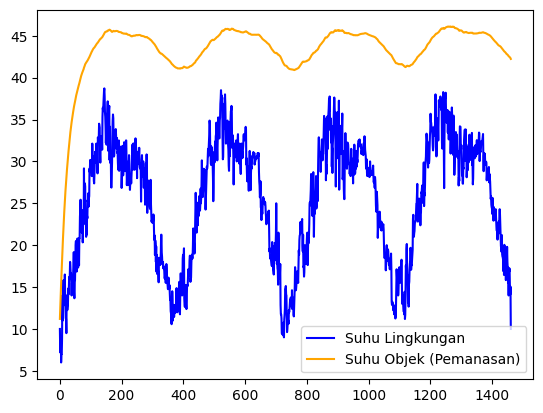

In [10]:
plt.plot(days, T_env, label="Suhu Lingkungan", color="blue")
plt.plot(days, T_heat, label="Suhu Objek (Pemanasan)", color="orange")
plt.legend()
plt.show()

# Analisis Pengaruh Konstanta k

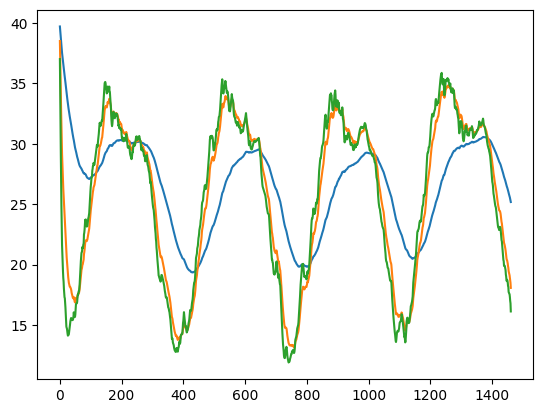

In [11]:
for k in [0.01, 0.05, 0.1]:
    T_sim = simulate_cooling(T_env, k=k)
    plt.plot(days, T_sim, label=f"k={k}")

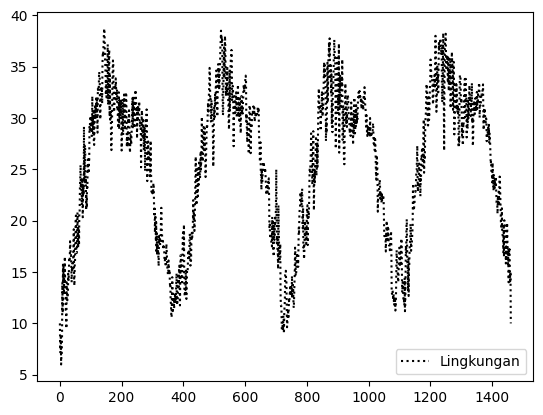

In [12]:
plt.plot(days, T_env, label="Lingkungan", color="black", linestyle=":")
plt.legend()
plt.show()